#### **Vanilla Autoencoders**

1.  Vanilla Autoencoder is a type of auto encoder that is used to learn all the compressed representations from the input data and obtain or reconstruct the original input from the compressed data.


#### **Steps used in this Algorithm:-**

1.  Import all the necessary Libraries

2.  Load the dataset

3.  Do Data Preprocessing and normalize the data

4.  Flatten Images

5.  Model Architecture and build the Vanilla Autoencoder model

6.  Compile the Autoencoder Model

7.  Train the Autoencoder Model

8.  Evaluate the model

9.  Reconstruct Images Using the Trained Model

10. Visualize Original vs Reconstructed Images

Encoder ----------> It plays an important role in compressing the input features

Decoder ----------> It plays an important role in reconstructing the original image

#### **Step 1: Import all the necessary Libraries**

In [332]:
import numpy             as np
import pandas            as pd
import matplotlib.pyplot as plt
import seaborn           as sns

from   tensorflow.keras.datasets   import  mnist
from   tensorflow.keras.models     import  Sequential
from   tensorflow.keras.layers     import  Dense, Dropout, BatchNormalization, Flatten, Reshape
from   tensorflow.keras.optimizers import  Adam

#### **OBSERVATIONS:**

1.  mnist ------> It is the dataset that represents the handwritten digits.

2.  Sequential ----> It is a sequential model that has a linear stack of layers.

3.  Dense --------> It has a dense connected layer of neurons

4.  Dropout -------> It is done to prevent the overfitting

5.  BatchNormalization -----> It is used to speed up the neural network training and improve the speed.

6.  Flatten -------> It is used to convert the 2D or 3D feature vectors into 1D vectors.

7.  Adam ------>

  (a.)  It is an optimizer that is used to update the weights during backpropogation.

  (b.)  It optimizes the learning rate so as to improve the convergence speed.

#### **Step 2: Load the dataset**

In [333]:
#### Load the dataset and divide it into training and testing data
(X_train, Y_train),(X_test, Y_test)=mnist.load_data()

In [334]:
X_train

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

In [335]:
X_test

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

In [336]:
print("Shape of the input training data is:", X_train.shape)
print("Shape of the input testing  data is:", X_test.shape)

Shape of the input training data is: (60000, 28, 28)
Shape of the input testing  data is: (10000, 28, 28)


In [337]:
Y_train

array([5, 0, 4, ..., 5, 6, 8], dtype=uint8)

In [338]:
Y_test

array([7, 2, 1, ..., 4, 5, 6], dtype=uint8)

In [339]:
print("Shape of the output training data is:", Y_train.shape)
print("Shape of the output testing  data is:", Y_test.shape)

Shape of the output training data is: (60000,)
Shape of the output testing  data is: (10000,)


#### **OBSERVATIONS:**

1.  The mnist dataset is divided into the training and the testing data.

    (a.)  the training data has 60,000 training images

    (b.)  the testing data has 10,000 testing images.

2. The input data is of the shape (No of images, pixel height, pixel width).

3.  The output data is of the shape of (No of images,).

4.  The input training data has 60,000 training images with 28 * 28 pixels

5.  The input testing data has 10,000 testing data images with 28 * 28 pixels.

6.  The Y_train and Y_test are the outputs that are not used in Autoencoders as the Autoencoder is used in unsupervised learning.

#### **Step 3: Do Data Preprocessing and normalize the data**

In [340]:
#### Data Preprocessing and normalize the inputs
X_train = X_train.astype('float32')/255.0

In [341]:
X_train

array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       ...,

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0.

In [342]:
X_test = X_test.astype('float32')/255.0

In [343]:
X_test

array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       ...,

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0.

#### **OBSERVATIONS:**

1.  Initially each pixel value ranges from 0 to 255.

2.  But after normalizing the pixel data i.e dividing the pixel data by 255.0, each pixel data has been reduced to 0-1 .

3.  The normalization has been done so that these normlaized values can be easily be fed into the neural network model and the model can easily train them.

#### **Step 4: Flatten Images**

In [344]:
X_train

array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       ...,

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0.

In [345]:
#### Check the shape of the training data
X_train.shape

(60000, 28, 28)

In [346]:
#### Check the dimension of the input training data
X_train.ndim

3

In [347]:
X_test

array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       ...,

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0.

In [348]:
#### Check the shape of the input testing data
X_test.shape

(10000, 28, 28)

In [349]:
#### Check the dimension of input testing data
X_test.ndim

3

In [350]:
len(X_train)

60000

In [351]:
len(X_test)

10000

In [352]:
#### Flatten the input data
X_train = X_train.reshape(len(X_train),28*28)
X_test  = X_test.reshape(len(X_test)  , 28*28)

In [353]:
X_train

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

In [354]:
X_train.shape

(60000, 784)

In [355]:
X_test

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

In [356]:
X_test.shape

(10000, 784)

In [357]:
#### Shape of the input data
print("Shape of the input training data after reshaping is:", X_train.shape)
print("Shape of the input testing  data after reshaping is:", X_test.shape)

Shape of the input training data after reshaping is: (60000, 784)
Shape of the input testing  data after reshaping is: (10000, 784)


In [358]:
#### Dimension of the input data
print("Dimension  of the input training data after reshaping is:", X_train.ndim)
print("Dimnension of the input testing  data after reshaping is:", X_test.ndim)

Dimension  of the input training data after reshaping is: 2
Dimnension of the input testing  data after reshaping is: 2


#### **OBSERVATIONS:**

1.  Here the input training data is of the form (60000,28,28)

2.  After performing the flattening operation it is converted into (60000,784)

3.  Here the input testing data is of the form (10000,28,28)

4.  After performing the flattening operation it is converted into (10000,784)

5. Now both the input training and testing data has the input in form of 2d because the fully dense connected layer expects the input to be in form of 2D.

#### **Step 5: Model Architecture and build the Vanilla Autoencoder model**

Input Image
(784)

      │
      ▼

Dense(128, ReLU)

      │
      ▼

Dense(32, ReLU)
(Bottleneck)

      │
      ▼

Dense(128, ReLU)

      │
      ▼

Dense(784, Sigmoid)

      │
      ▼

Reconstructed Image
(784)

In [359]:
#### Construct the Autoencoder model
model = Sequential([
  ############################################# Encoder #####################################################################
    #### construct the first dense layer
    Dense(128,activation='relu',input_shape = (784,))                                 ,
    #### Add a Dropout layer
    #Dropout(0.5)                                                                      ,
    #### Add a Batch Normalization layer
    #BatchNormalization()                                                              ,

    #### Construct the second dense layer
    Dense(32,activation='relu')                                                       ,
    #### Add a dropout layer
    #Dropout(0.5)                                                                      ,
    #### Add a BatchNormalization layer
    #BatchNormalization()                                                              ,
   ############################################# Decoder #####################################################################
    #### Construct the third dense layer
    Dense(128,activation='relu')                                                      ,
    #### Add a dropout layer
    #Dropout(0.5)                                                                      ,
    #### Add a BatchNormalization layer
    #BatchNormalization()                                                              ,
    #### Construct the final dense layer
    Dense(784,activation='sigmoid')
])

In [360]:
model

<Sequential name=sequential_8, built=True>

#### **OBSERVATIONS:**

1. The object for autoencoder sequential model has been initialized.

2. First of all we have the total input features as 784 as mnist image has 28 rows * 28 columns that has been flattened into 784 features.

3. Then we encode and compress all the input 784 features to 128 features

4. Again we perform the encoding and compress all the input 128 features to 32 features

5. The above process is known as encoding.

6. Then begins with the decoding process

7. We decode and reconstruct the features from 32 to 128 features

8. Again we decode and reconstruct the features from 128 to 784 features

9. This process is known as decoding where we reconstruct the original input image.

10. So here in this model, we try to compress the size of the input image so as to extract all the essential information from it and then we reconstruct the original image from it

In [361]:
#### get the summary of the model
model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_32 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 209,968 (820.19 KB)

 Trainable params: 209,968 (820.19 KB)

 Non-trainable params: 0 (0.00 B)

#### **Step 6: Compile the Autoencoder Model**

In [362]:
#### compile the model
model.compile(
    optimizer       =       'adam'                             ,
    loss            =       'binary_crossentropy'              ,
    metrics         =       ['accuracy']
)

#### **OBSERVATIONS:**

1. The model has been made ready for the training purpose with the help of the following parameters.

    (a.) optimizer = 'adam' . It is used to make the learning rate as dynamic and improves the convergence speed.

    (b.) loss = 'binary_crossentropy'. It is a binary loss function as it is used to solve the binary classification problem.

    (c.) metrics = 'accuracy'. It is used to evaluate the performance of the model

In [363]:
X_train.shape

(60000, 784)

In [364]:
Y_train.shape

(60000,)

#### **Step 7: Train the Autoencoder Model**

In [365]:
#### Train the autoencoder model
history=model.fit(
    X_train                                                 ,
    X_train                                                 ,
    epochs              =       10                          ,
    batch_size          =       256                         ,
    validation_split    =       0.2                         ,
    verbose             =       1
)

Epoch 1/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.0081 - loss: 0.2486 - val_accuracy: 0.0094 - val_loss: 0.1664
Epoch 2/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.0121 - loss: 0.1458 - val_accuracy: 0.0110 - val_loss: 0.1323
Epoch 3/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.0113 - loss: 0.1249 - val_accuracy: 0.0121 - val_loss: 0.1195
Epoch 4/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.0115 - loss: 0.1151 - val_accuracy: 0.0086 - val_loss: 0.1121
Epoch 5/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.0105 - loss: 0.1088 - val_accuracy: 0.0117 - val_loss: 0.1073
Epoch 6/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.0107 - loss: 0.1048 - val_accuracy: 0.0102 - val_loss: 0.1040
Epoch 7/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.0105 - loss: 0.1024 - val_accuracy: 0.0113 - val_loss: 0.1023
Epoch 8/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.0106 - loss: 0.1007 - val_accu

In [366]:
history

#### **OBSERVATIONS:**

1.  The Vanilla autoencoder model has been trained with the following parameters:

    (a.)  X_train, X_train ------->
    
        (i) We have only used the input training data as the autoencoder is an unsupervised machine learning model.
        
        (ii) The Autoencoder only learns the patterns from the data but does not produce any output.

    (b.) epochs = 10 -----------> 10 iterations are needed to train the model

    (c.) batch_size = 256 ------> 256 elements are taken in a batch and processed one after the other in each iterations

    (d.) validation_split = 0.2 ------> 20 % of the data is used for validation as the model can check the performance on the unseen data.

    (e.) verbose = 1 --------> It controls the training output.

2. After training the model, we see that the accuracy and the validation accuracy of the model has increased but the loss and the validation loss has decreased.

3. So the model is working fine.

#### **Step 8: Evaluate the model**

In [367]:
loss, accuracy = model.evaluate(X_test, X_test,verbose=0)
print(f"Loss of the model is: {loss:.4f}")
print(f"Accuracy of the model is: {accuracy:.4f}")

Loss of the model is: 0.0962
Accuracy of the model is: 0.0125


#### **OBSERVATIONS:**

1.  Here the model evaluation is done with the input testing data not with any outpout data.

2.  This is because the Vanilla Autoencoder model is an unsupervised machine learning model which can only work with the input not with output.

3.  It only learns the patterns from the data.

#### **Step 9: Reconstruct Images Using the Trained Model**

In [368]:
#### Predict the output of the model using the input testing data
Y_pred = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [369]:
Y_pred

array([[1.65077854e-08, 1.78163118e-09, 3.37240746e-09, ...,
        3.22534732e-09, 1.18333986e-07, 5.49909229e-10],
       [4.42654857e-10, 2.76275502e-10, 1.27903049e-10, ...,
        1.36512330e-08, 5.04109476e-10, 2.72092504e-09],
       [2.66441691e-09, 4.39427994e-10, 1.29369857e-08, ...,
        1.20094290e-08, 2.07300976e-09, 1.01136086e-08],
       ...,
       [1.05015406e-11, 9.86651594e-11, 1.23382873e-10, ...,
        9.25613614e-11, 1.28279540e-10, 1.18718958e-11],
       [9.06473577e-11, 2.58076249e-09, 2.76347278e-09, ...,
        2.14925011e-09, 2.84066415e-09, 4.12020140e-10],
       [1.63117776e-14, 1.49011467e-12, 1.75063436e-12, ...,
        4.37620773e-12, 6.04242893e-13, 2.48496059e-12]], dtype=float32)

#### **OBSERVATIONS:**

1. The output of the model has been predicted using the input testing data.

#### **Step 10: Visualize Original vs Reconstructed Images**

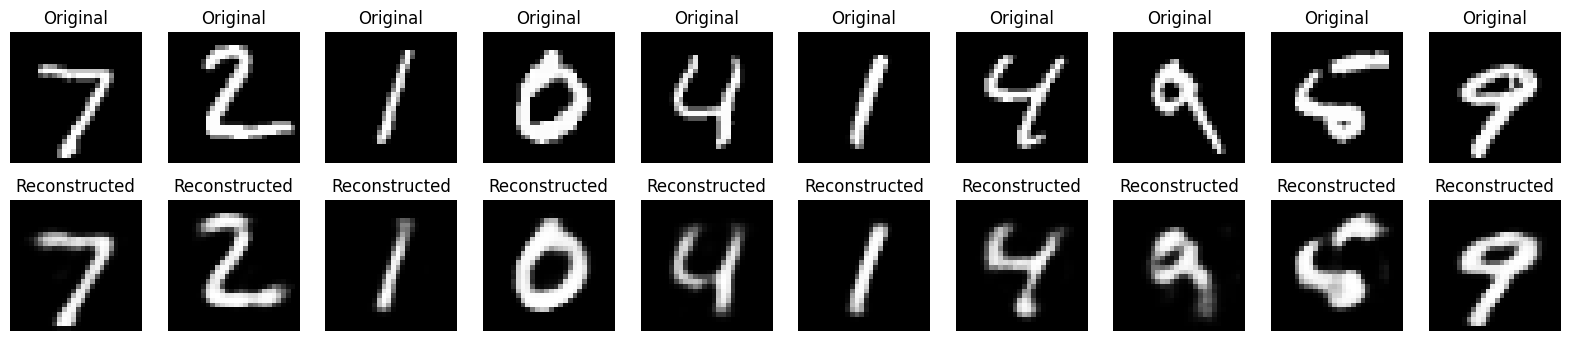

In [370]:
n = 10  # Show 10 images
plt.figure(figsize=(20,4))

for i in range(n):
    # Display original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(X_test[i].reshape(28, 28), cmap="gray")
    ax.set_title("Original")
    plt.axis("off")

    # Display reconstruction
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(Y_pred[i].reshape(28, 28), cmap="gray")
    ax.set_title("Reconstructed")
    plt.axis("off")

plt.show()

#### **OBSERVATIONS:**

1. Here we have performed the visualization between the Original vs Reconstructed Image.

2.  After performing the Vanilla Autoencoder, we can see that the original and the reconstructed image looks the same.

3. So the Vanilla Autoencoder works fine.
